<h1>Train — ResNet-18 (baseline)</h1>

Trains and evaluates the ResNet-18 baseline classifier, then saves its results (`results_resnet18.pkl`) and weights (`{COMPONENT}_resnet18_cnn.pt`) to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): NoordelikeWerke
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1692 | Val: 410 | Test: 405


## Define the model (Transfer Learning with ResNet-18)

In [2]:
model_resnet18 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

num_ftrs = model_resnet18.fc.in_features
model_resnet18.fc = nn.Linear(num_ftrs, num_classes)  # no hidden layers — this one predates the tuning sweep

model_resnet18 = model_resnet18.to(device)

# ---------------------------------------------------------
# Loss and optimizer, with class weights for the imbalanced classes
# ---------------------------------------------------------
class_weights = make_class_weights(train_ds)
print("Applying class weights to loss function:")
for name, w in zip(class_names, class_weights.cpu().numpy()):
    print(f"  {name:<15s}: {w:.3f}")

criterion_resnet18 = nn.CrossEntropyLoss(weight=class_weights)
optimizer_resnet18 = optim.Adam(model_resnet18.parameters(), lr=5e-4, weight_decay=WEIGHT_DECAY)

# mode='min' because we want to minimize loss; factor=0.5 halves the LR when
# triggered; patience=3 waits 3 epochs with no improvement before reducing it
scheduler_resnet18 = ReduceLROnPlateau(optimizer_resnet18, mode='min', factor=0.5, patience=3)

Applying class weights to loss function:
  Dysfunctional  : 2.097
  Empty          : 1.249
  Functional     : 0.320
  Scum           : 0.333


## Train, then plot training curves

[ResNet-18] Epoch   1/100 | LR: 5.00e-04 | train loss 0.9395 acc 0.605 | val loss 0.6809 acc 0.715 *


[ResNet-18] Epoch   2/100 | LR: 5.00e-04 | train loss 0.6580 acc 0.715 | val loss 0.5316 acc 0.751 *


[ResNet-18] Epoch   3/100 | LR: 5.00e-04 | train loss 0.6096 acc 0.737 | val loss 0.6647 acc 0.715


[ResNet-18] Epoch   4/100 | LR: 5.00e-04 | train loss 0.5096 acc 0.780 | val loss 0.5962 acc 0.771


[ResNet-18] Epoch   5/100 | LR: 5.00e-04 | train loss 0.4895 acc 0.788 | val loss 0.5126 acc 0.810 *


...

[ResNet-18] Epoch  21/100 | LR: 1.25e-04 | train loss 0.1037 acc 0.949 | val loss 0.3384 acc 0.883


[ResNet-18] Epoch  22/100 | LR: 1.25e-04 | train loss 0.0931 acc 0.959 | val loss 0.3345 acc 0.880


[ResNet-18] Epoch  23/100 | LR: 6.25e-05 | train loss 0.0811 acc 0.967 | val loss 0.3741 acc 0.876


[ResNet-18] Epoch  24/100 | LR: 6.25e-05 | train loss 0.0606 acc 0.976 | val loss 0.3479 acc 0.888


[ResNet-18] Epoch  25/100 | LR: 6.25e-05 | train loss 0.0654 acc 0.971 | val loss 0.3238 acc 0.898

[ResNet-18] No val loss improvement for 10 epochs — stopping early at epoch 25.

[ResNet-18] Restored best checkpoint (val loss = 0.3061)


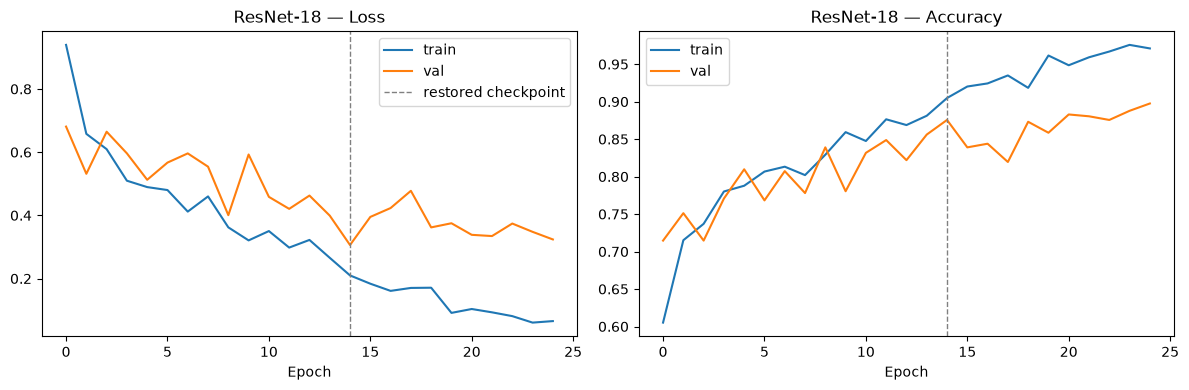

In [3]:
history_resnet18 = train_model(
    model_resnet18, train_loader, val_loader, optimizer_resnet18, scheduler_resnet18,
    criterion_resnet18, EPOCHS, EARLY_STOP_PATIENCE, "ResNet-18",
)
plot_training_curves(history_resnet18, "ResNet-18")

## Evaluate on the test set

[ResNet-18] Test accuracy: 0.793


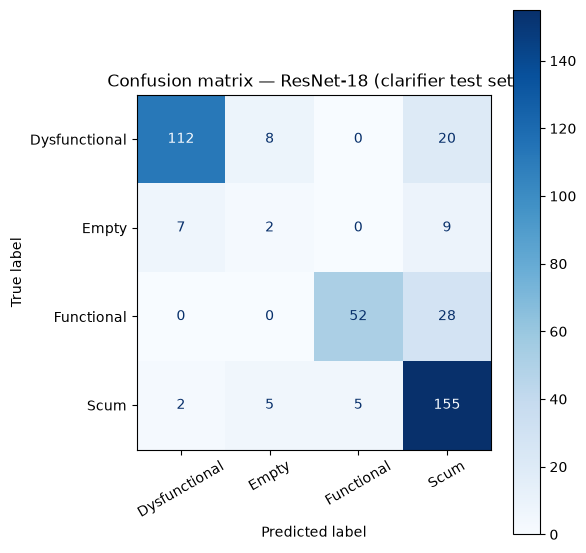

               precision    recall  f1-score   support

Dysfunctional      0.926     0.800     0.858       140
        Empty      0.133     0.111     0.121        18
   Functional      0.912     0.650     0.759        80
         Scum      0.731     0.928     0.818       167

     accuracy                          0.793       405
    macro avg      0.676     0.622     0.639       405
 weighted avg      0.808     0.793     0.789       405



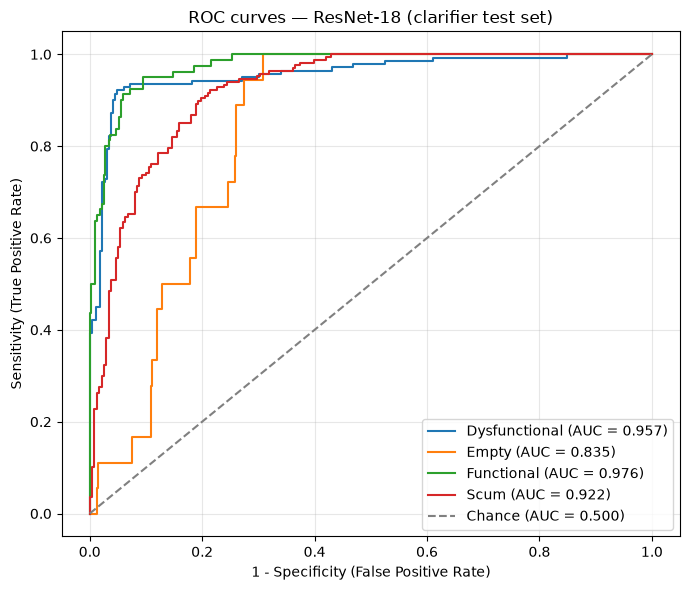

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.957
  Empty          : 0.835
  Functional     : 0.976
  Scum           : 0.922

Mean AUC (over 4/4 classes with test examples): 0.923


(np.float64(0.7925925925925926),
 {'Dysfunctional': 0.9573584905660377,
  'Empty': 0.8354866494401378,
  'Functional': 0.9757692307692307,
  'Scum': 0.9216273335681577})

In [4]:
evaluate_and_record(
    model_resnet18, test_loader, "ResNet-18", history_resnet18,
    img_size=IMG_TARGET_SIZE, hidden_layers=0, neurons=None,
)

## Save results + model weights to disk

This is the step the results notebook depends on — it pickles the metrics/history and saves the model state dict so nothing needs to be kept in memory or re-trained.

In [5]:
save_result("ResNet-18", "resnet18")

Saved results to ../results/results_clarifier_resnet18_NoordelikeWerke.pkl


Saved model weights to ../models/clarifier_resnet18_cnn.pt
